In [1]:
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split

# =========================
# 1. Paths
# =========================
TRAIN_DIR = "/kaggle/input/datasets/jubayerhasan755/alzheimer-dataset02/alzheimer/train"
TEST_DIR  = "/kaggle/input/datasets/jubayerhasan755/alzheimer-dataset02/alzheimer/test"

# =========================
# 2. Set ratio for THIS notebook
# Example: 80:20
# Change this per notebook
# =========================
TRAIN_PERCENT = 30
TEST_PERCENT = 70

assert TRAIN_PERCENT + TEST_PERCENT == 100

# =========================
# 3. Allowed image formats
# =========================
IMG_EXTENSIONS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")

# =========================
# 4. Label normalization
# Adjust after checking your real folder names
# =========================
LABEL_MAP = {
    "AD": "AD",
    "MCI": "MCI",
    "CN": "CN",

    "Alzheimer": "AD",
    "MildCognitiveImpairment": "MCI",
    "CognitivelyNormal": "CN",
    "NonDemented": "CN",
    "VeryMildDemented": "MCI",
    "MildDemented": "MCI",
    "ModerateDemented": "AD",
}

def normalize_label(folder_name):
    return LABEL_MAP.get(folder_name, folder_name)

# =========================
# 5. Collect image paths
# =========================
def collect_images_from_root(root_dir):
    rows = []
    class_folders = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])

    for class_name in class_folders:
        class_path = os.path.join(root_dir, class_name)
        image_files = []
        for ext in IMG_EXTENSIONS:
            image_files.extend(glob.glob(os.path.join(class_path, ext)))

        normalized_label = normalize_label(class_name)

        for img_path in image_files:
            rows.append({
                "filepath": img_path,
                "label": normalized_label,
                "source_folder": os.path.basename(root_dir)
            })

    return pd.DataFrame(rows)

# =========================
# 6. Build full dataset
# =========================
train_df = collect_images_from_root(TRAIN_DIR)
test_df  = collect_images_from_root(TEST_DIR)

full_df = pd.concat([train_df, test_df], ignore_index=True)
full_df = full_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Total images:", len(full_df))
print("\nClass distribution:")
print(full_df["label"].value_counts())

print("\nUnique labels:", full_df["label"].unique())

# =========================
# 7. Create ONE stratified split for this notebook
# =========================
test_size = TEST_PERCENT / 100.0

train_val_df, test_split_df = train_test_split(
    full_df,
    test_size=test_size,
    stratify=full_df["label"],
    random_state=42
)

# 10% of training portion goes to validation
train_split_df, val_split_df = train_test_split(
    train_val_df,
    test_size=0.10,
    stratify=train_val_df["label"],
    random_state=42
)

# =========================
# 8. Show split summary
# =========================
print(f"\n===== Split {TRAIN_PERCENT}:{TEST_PERCENT} =====")
print(f"Train samples: {len(train_split_df)}")
print(train_split_df["label"].value_counts())

print(f"\nValidation samples: {len(val_split_df)}")
print(val_split_df["label"].value_counts())

print(f"\nTest samples: {len(test_split_df)}")
print(test_split_df["label"].value_counts())

# =========================
# 9. Optional: save CSVs for this notebook
# =========================
OUTPUT_DIR = f"/kaggle/working/split_{TRAIN_PERCENT}_{TEST_PERCENT}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_split_df.to_csv(os.path.join(OUTPUT_DIR, "train.csv"), index=False)
val_split_df.to_csv(os.path.join(OUTPUT_DIR, "val.csv"), index=False)
test_split_df.to_csv(os.path.join(OUTPUT_DIR, "test.csv"), index=False)

print("\nSaved split files to:", OUTPUT_DIR)

Total images: 5154

Class distribution:
label
MCI    2590
CN     1440
AD     1124
Name: count, dtype: int64

Unique labels: ['CN' 'AD' 'MCI']

===== Split 30:70 =====
Train samples: 1391
label
MCI    699
CN     389
AD     303
Name: count, dtype: int64

Validation samples: 155
label
MCI    78
CN     43
AD     34
Name: count, dtype: int64

Test samples: 3608
label
MCI    1813
CN     1008
AD      787
Name: count, dtype: int64

Saved split files to: /kaggle/working/split_30_70


In [2]:
import os
import time
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights


# Fixed label mapping
label_to_idx = {
    "AD": 0,
    "MCI": 1,
    "CN": 2
}

idx_to_label = {v: k for k, v in label_to_idx.items()}

print(label_to_idx)

class AlzheimerDataset(Dataset):
    def __init__(self, dataframe, transform=None, label_map=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_map = label_map

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = row["filepath"]
        label_name = row["label"]

        # Load image and convert to RGB
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.label_map[label_name]

        return image, label


IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = AlzheimerDataset(
    dataframe=train_split_df,
    transform=train_transform,
    label_map=label_to_idx
)

val_dataset = AlzheimerDataset(
    dataframe=val_split_df,
    transform=val_test_transform,
    label_map=label_to_idx
)

test_dataset = AlzheimerDataset(
    dataframe=test_split_df,
    transform=val_test_transform,
    label_map=label_to_idx
)

BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

{'AD': 0, 'MCI': 1, 'CN': 2}
Train batches: 44
Val batches: 5
Test batches: 113


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

weights = MobileNet_V2_Weights.DEFAULT
model = mobilenet_v2(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 3)

model = model.to(device)
print(model)


for param in model.parameters():
    param.requires_grad = True


class_counts = train_split_df["label"].value_counts()
print("Train class counts:\n", class_counts)

# order must match label_to_idx
counts = np.array([
    class_counts["AD"],
    class_counts["MCI"],
    class_counts["CN"]
], dtype=np.float32)

class_weights = counts.sum() / (len(counts) * counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights)


criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input batch shape:", images.shape)   # expected: [B, 3, 224, 224]
print("Label batch shape:", labels.shape)   # expected: [B]
print("Output shape:", outputs.shape)       # expected: [B, 3]




Using device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 110MB/s] 


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [4]:
import os
import copy
import time
import matplotlib.pyplot as plt

NUM_EPOCHS = 50
PATIENCE = 50   # early stopping patience
SAVE_DIR = "/kaggle/working/mobilenetv2_results"
os.makedirs(SAVE_DIR, exist_ok=True)

best_model_path = os.path.join(SAVE_DIR, "best_mobilenetv2.pth")


def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct / total

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples

    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            running_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples

    return epoch_loss, epoch_acc




In [5]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_acc = 0.0
best_epoch = 0
epochs_without_improvement = 0

start_training_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    epoch_time = time.time() - epoch_start_time

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Time: {epoch_time:.2f}s")

    # Save best model based on validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        epochs_without_improvement = 0

        torch.save(model.state_dict(), best_model_path)
        print(f" Best model saved at epoch {best_epoch} with val_acc={best_val_acc:.4f}")
    else:
        epochs_without_improvement += 1

    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered after {epoch+1} epochs.")
        break

total_training_time = time.time() - start_training_time

print("\nTraining complete.")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Best Epoch: {best_epoch}")
print(f"Total Training Time: {total_training_time:.2f} seconds")
print(f"Best model saved to: {best_model_path}")

Epoch [1/50] | Train Loss: 1.0533 | Train Acc: 0.4615 | Val Loss: 1.0591 | Val Acc: 0.4710 | Time: 13.33s
 Best model saved at epoch 1 with val_acc=0.4710
Epoch [2/50] | Train Loss: 0.9258 | Train Acc: 0.5924 | Val Loss: 0.9491 | Val Acc: 0.6065 | Time: 5.81s
 Best model saved at epoch 2 with val_acc=0.6065
Epoch [3/50] | Train Loss: 0.7652 | Train Acc: 0.6671 | Val Loss: 0.8328 | Val Acc: 0.6194 | Time: 5.97s
 Best model saved at epoch 3 with val_acc=0.6194
Epoch [4/50] | Train Loss: 0.5958 | Train Acc: 0.7570 | Val Loss: 0.7433 | Val Acc: 0.6387 | Time: 6.36s
 Best model saved at epoch 4 with val_acc=0.6387
Epoch [5/50] | Train Loss: 0.4258 | Train Acc: 0.8476 | Val Loss: 0.6868 | Val Acc: 0.7226 | Time: 6.02s
 Best model saved at epoch 5 with val_acc=0.7226
Epoch [6/50] | Train Loss: 0.3335 | Train Acc: 0.8792 | Val Loss: 0.4247 | Val Acc: 0.8581 | Time: 5.96s
 Best model saved at epoch 6 with val_acc=0.8581
Epoch [7/50] | Train Loss: 0.2506 | Train Acc: 0.9008 | Val Loss: 0.3832 | 

Best model loaded for final evaluation.
Training history saved to: /kaggle/working/mobilenetv2_results/training_history.csv


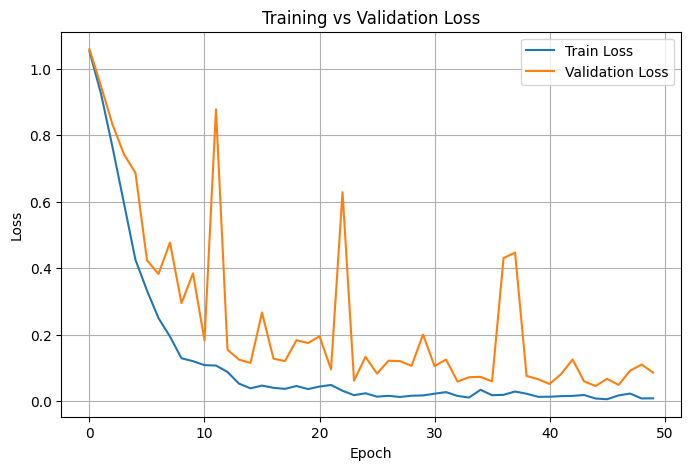

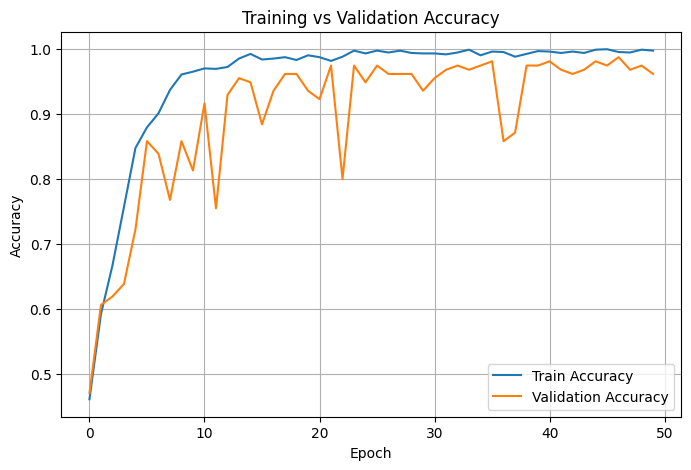

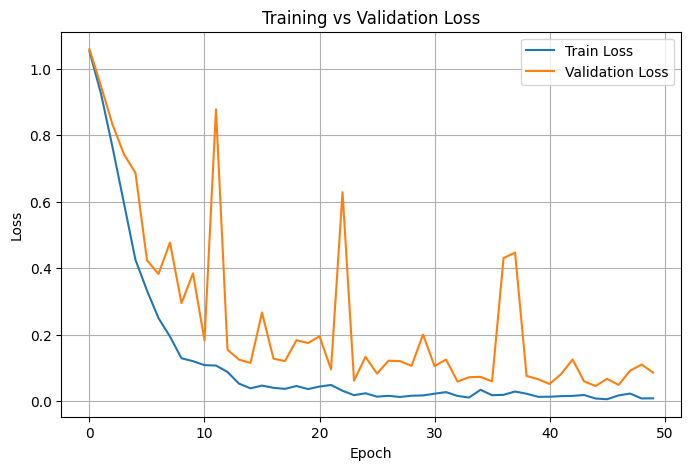

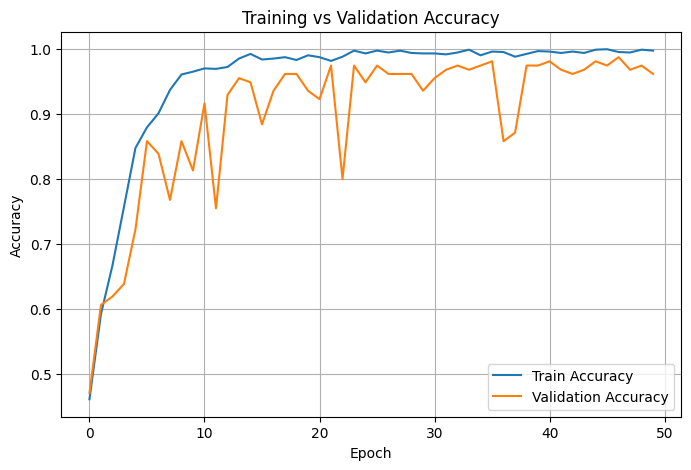

In [6]:
model.load_state_dict(torch.load(best_model_path))
model = model.to(device)
model.eval()

print("Best model loaded for final evaluation.")

history_df = pd.DataFrame({
    "epoch": list(range(1, len(history["train_loss"]) + 1)),
    "train_loss": history["train_loss"],
    "val_loss": history["val_loss"],
    "train_acc": history["train_acc"],
    "val_acc": history["val_acc"]
})

history_csv_path = os.path.join(SAVE_DIR, "training_history.csv")
history_df.to_csv(history_csv_path, index=False)

print("Training history saved to:", history_csv_path)

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Save Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "loss_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

# Save Accuracy Curve
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "accuracy_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

Total Testing Time: 22.72 seconds
Shapes:
Labels: (3608,)
Predictions: (3608,)
Probabilities: (3608, 3)
Overall Test Accuracy: 0.9684

Per-Class Accuracy:
AD: 0.9517
MCI: 0.9895
CN: 0.9435

Macro Metrics:
Precision (Macro): 0.9673
Recall (Macro):    0.9616
F1-score (Macro):  0.9642

Weighted Metrics:
Precision (Weighted): 0.9687
Recall (Weighted):    0.9684
F1-score (Weighted):  0.9683

Classification Report:

              precision    recall  f1-score   support

          AD     0.9457    0.9517    0.9487       787
         MCI     0.9676    0.9895    0.9785      1813
          CN     0.9886    0.9435    0.9655      1008

    accuracy                         0.9684      3608
   macro avg     0.9673    0.9616    0.9642      3608
weighted avg     0.9687    0.9684    0.9683      3608



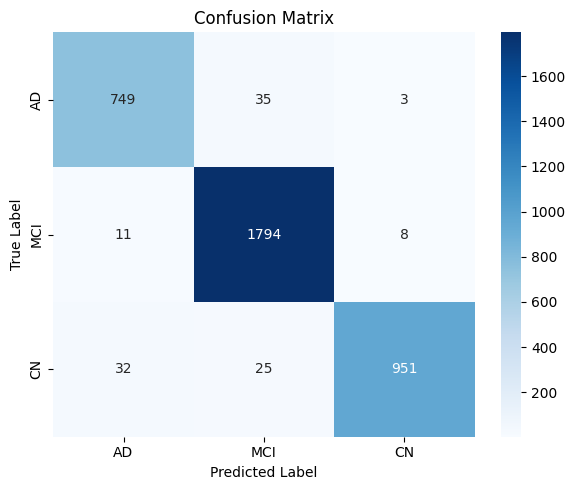

In [7]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

model.eval()

all_labels = []
all_preds = []
all_probs = []

start_test_time = time.time()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

total_test_time = time.time() - start_test_time

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

print(f"Total Testing Time: {total_test_time:.2f} seconds")
print("Shapes:")
print("Labels:", all_labels.shape)
print("Predictions:", all_preds.shape)
print("Probabilities:", all_probs.shape)


overall_accuracy = accuracy_score(all_labels, all_preds)
print(f"Overall Test Accuracy: {overall_accuracy:.4f}")

class_names = ["AD", "MCI", "CN"]

cm = confusion_matrix(all_labels, all_preds)

per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("\nPer-Class Accuracy:")
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {per_class_accuracy[i]:.4f}")

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="macro", zero_division=0
)

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted", zero_division=0
)

print("\nMacro Metrics:")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro):    {recall_macro:.4f}")
print(f"F1-score (Macro):  {f1_macro:.4f}")

print("\nWeighted Metrics:")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Weighted):    {recall_weighted:.4f}")
print(f"F1-score (Weighted):  {f1_weighted:.4f}")


report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("\nClassification Report:\n")
print(report)


cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()





Per-Class ROC-AUC:
AD: 0.9944
MCI: 0.9972
CN: 0.9973

Macro ROC-AUC:    0.9963
Weighted ROC-AUC: 0.9966


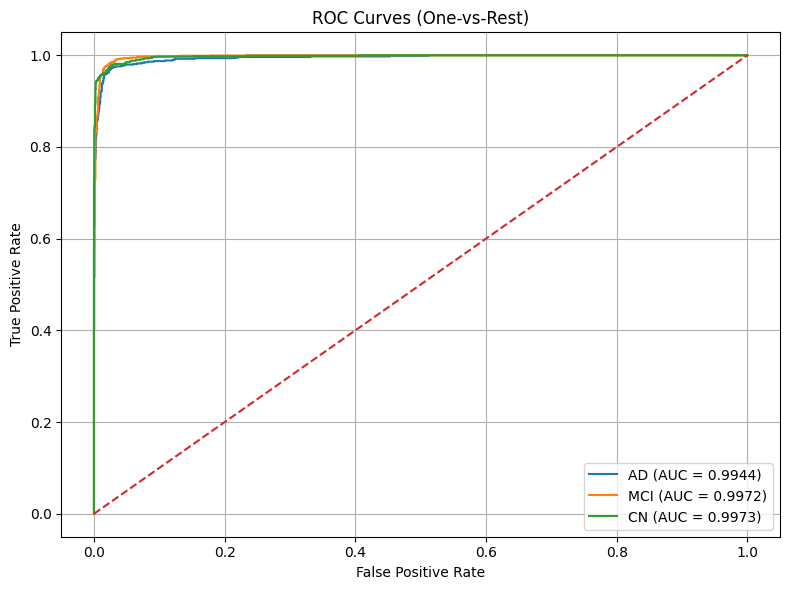

Final results saved to: /kaggle/working/mobilenetv2_results/final_results.csv


,Model,Input_Size,Overall_Accuracy,AD_Accuracy,MCI_Accuracy,CN_Accuracy,Precision_Macro,Recall_Macro,F1_Macro,Precision_Weighted,...,F1_Weighted,AD_ROC_AUC,MCI_ROC_AUC,CN_ROC_AUC,Macro_ROC_AUC,Weighted_ROC_AUC,Training_Time_sec,Testing_Time_sec,Best_Val_Accuracy,Best_Epoch
0,MobileNetV2,224x224,0.968404,0.951715,0.98952,0.943452,0.967303,0.961563,0.964213,0.968701,...,0.968341,0.994425,0.997172,0.997289,0.996295,0.996605,320.362599,22.715252,0.987097,47


Classification report saved to: /kaggle/working/mobilenetv2_results/classification_report.csv


,precision,recall,f1-score,support
AD,0.945707,0.951715,0.948702,787.000000
MCI,0.967638,0.989520,0.978457,1813.000000
CN,0.988565,0.943452,0.965482,1008.000000
accuracy,0.968404,0.968404,0.968404,0.968404
macro avg,0.967303,0.961563,0.964213,3608.000000
weighted avg,0.968701,0.968404,0.968341,3608.000000


In [8]:
# Binarize labels for multiclass ROC-AUC
all_labels_bin = label_binarize(all_labels, classes=[0, 1, 2])

# Per-class ROC-AUC
roc_auc_per_class = {}
fpr = {}
tpr = {}
roc_auc_curves = {}

for i, class_name in enumerate(class_names):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc_curves[i] = auc(fpr[i], tpr[i])
    roc_auc_per_class[class_name] = roc_auc_curves[i]

# Macro-average ROC-AUC
macro_roc_auc = roc_auc_score(
    all_labels_bin,
    all_probs,
    average="macro",
    multi_class="ovr"
)

weighted_roc_auc = roc_auc_score(
    all_labels_bin,
    all_probs,
    average="weighted",
    multi_class="ovr"
)

print("\nPer-Class ROC-AUC:")
for class_name, score in roc_auc_per_class.items():
    print(f"{class_name}: {score:.4f}")

print(f"\nMacro ROC-AUC:    {macro_roc_auc:.4f}")
print(f"Weighted ROC-AUC: {weighted_roc_auc:.4f}")

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], label=f"{class_name} (AUC = {roc_auc_curves[i]:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "roc_curves.png"), dpi=300, bbox_inches="tight")
plt.show()


results_dict = {
    "Model": "MobileNetV2",
    "Input_Size": f"{IMG_SIZE}x{IMG_SIZE}",
    "Overall_Accuracy": overall_accuracy,

    "AD_Accuracy": per_class_accuracy[0],
    "MCI_Accuracy": per_class_accuracy[1],
    "CN_Accuracy": per_class_accuracy[2],

    "Precision_Macro": precision_macro,
    "Recall_Macro": recall_macro,
    "F1_Macro": f1_macro,

    "Precision_Weighted": precision_weighted,
    "Recall_Weighted": recall_weighted,
    "F1_Weighted": f1_weighted,

    "AD_ROC_AUC": roc_auc_per_class["AD"],
    "MCI_ROC_AUC": roc_auc_per_class["MCI"],
    "CN_ROC_AUC": roc_auc_per_class["CN"],

    "Macro_ROC_AUC": macro_roc_auc,
    "Weighted_ROC_AUC": weighted_roc_auc,

    "Training_Time_sec": total_training_time,
    "Testing_Time_sec": total_test_time,
    "Best_Val_Accuracy": best_val_acc,
    "Best_Epoch": best_epoch
}

results_df = pd.DataFrame([results_dict])
results_csv_path = os.path.join(SAVE_DIR, "final_results.csv")
results_df.to_csv(results_csv_path, index=False)

print("Final results saved to:", results_csv_path)
display(results_df)

report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
report_csv_path = os.path.join(SAVE_DIR, "classification_report.csv")
report_df.to_csv(report_csv_path, index=True)

print("Classification report saved to:", report_csv_path)
display(report_df)

In [9]:
!pip install -q thop

from thop import profile
from thop import clever_format

# Make a dummy input
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)

# Compute FLOPs and parameters
flops, params = profile(model, inputs=(dummy_input,), verbose=False)

# Convert to readable format
flops_readable, params_readable = clever_format([flops, params], "%.3f")

print(f"Input Size: 1 x 3 x {IMG_SIZE} x {IMG_SIZE}")
print(f"FLOPs per inference: {flops_readable}")
print(f"Parameters: {params_readable}")

gflops = flops / 1e9
million_params = params / 1e6

print(f"GFLOPs per inference: {gflops:.4f}")
print(f"Parameters (Millions): {million_params:.4f} M")

num_test_samples = len(test_dataset)
avg_inference_time_per_image = total_test_time / num_test_samples

print(f"Total test samples: {num_test_samples}")
print(f"Average inference time per image: {avg_inference_time_per_image:.6f} seconds")

avg_inference_time_ms = avg_inference_time_per_image * 1000
print(f"Average inference time per image: {avg_inference_time_ms:.4f} ms")



Input Size: 1 x 3 x 224 x 224
FLOPs per inference: 326.211M
Parameters: 2.228M
GFLOPs per inference: 0.3262
Parameters (Millions): 2.2277 M
Total test samples: 3608
Average inference time per image: 0.006296 seconds
Average inference time per image: 6.2958 ms


In [10]:
compute_summary = {
    "Model": "MobileNetV2",
    "Input_Size": f"{IMG_SIZE}x{IMG_SIZE}",
    "GFLOPs_per_Inference": gflops,
    "Parameters_Million": million_params,
    "Total_Test_Time_sec": total_test_time,
    "Avg_Inference_Time_per_Image_ms": avg_inference_time_ms,
    "Total_Training_Time_sec": total_training_time
}

compute_df = pd.DataFrame([compute_summary])

compute_csv_path = os.path.join(SAVE_DIR, "compute_summary.csv")
compute_df.to_csv(compute_csv_path, index=False)

print("Compute summary saved to:", compute_csv_path)
display(compute_df)

final_summary_dict = {
    "Model": "MobileNetV2",
    "Train_Test_Split": f"{TRAIN_PERCENT}:{TEST_PERCENT}",
    "Input_Size": f"{IMG_SIZE}x{IMG_SIZE}",

    "Accuracy": overall_accuracy,
    "AD_Acc": per_class_accuracy[0],
    "MCI_Acc": per_class_accuracy[1],
    "CN_Acc": per_class_accuracy[2],

    "Precision_Macro": precision_macro,
    "Recall_Macro": recall_macro,
    "F1_Macro": f1_macro,

    "Macro_ROC_AUC": macro_roc_auc,

    "Training_Time_sec": total_training_time,
    "Testing_Time_sec": total_test_time,
    "Avg_Inference_Time_ms": avg_inference_time_ms,
    "GFLOPs": gflops,
    "Params_M": million_params,
    "Best_Epoch": best_epoch,
    "Best_Val_Acc": best_val_acc
}

final_summary_df = pd.DataFrame([final_summary_dict])

final_summary_path = os.path.join(SAVE_DIR, "report_ready_summary.csv")
final_summary_df.to_csv(final_summary_path, index=False)

print("Report-ready summary saved to:", final_summary_path)
display(final_summary_df)

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_csv_path = os.path.join(SAVE_DIR, "confusion_matrix_values.csv")
cm_df.to_csv(cm_csv_path)

print("Confusion matrix values saved to:", cm_csv_path)
display(cm_df)



Compute summary saved to: /kaggle/working/mobilenetv2_results/compute_summary.csv


,Model,Input_Size,GFLOPs_per_Inference,Parameters_Million,Total_Test_Time_sec,Avg_Inference_Time_per_Image_ms,Total_Training_Time_sec
0,MobileNetV2,224x224,0.326211,2.227715,22.715252,6.295802,320.362599


Report-ready summary saved to: /kaggle/working/mobilenetv2_results/report_ready_summary.csv


,Model,Train_Test_Split,Input_Size,Accuracy,AD_Acc,MCI_Acc,CN_Acc,Precision_Macro,Recall_Macro,F1_Macro,Macro_ROC_AUC,Training_Time_sec,Testing_Time_sec,Avg_Inference_Time_ms,GFLOPs,Params_M,Best_Epoch,Best_Val_Acc
0,MobileNetV2,30:70,224x224,0.968404,0.951715,0.98952,0.943452,0.967303,0.961563,0.964213,0.996295,320.362599,22.715252,6.295802,0.326211,2.227715,47,0.987097


Confusion matrix values saved to: /kaggle/working/mobilenetv2_results/confusion_matrix_values.csv


,AD,MCI,CN
AD,749,35,3
MCI,11,1794,8
CN,32,25,951


In [11]:
failure_modes = []

for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j:
            failure_modes.append({
                "True_Class": class_names[i],
                "Predicted_As": class_names[j],
                "Count": cm[i, j]
            })

failure_modes_df = pd.DataFrame(failure_modes)
failure_modes_df = failure_modes_df.sort_values(by="Count", ascending=False).reset_index(drop=True)

failure_modes_path = os.path.join(SAVE_DIR, "failure_modes.csv")
failure_modes_df.to_csv(failure_modes_path, index=False)

print("Failure modes saved to:", failure_modes_path)
display(failure_modes_df.head(10))

Failure modes saved to: /kaggle/working/mobilenetv2_results/failure_modes.csv


,True_Class,Predicted_As,Count
0,AD,MCI,35
1,CN,AD,32
2,CN,MCI,25
3,MCI,AD,11
4,MCI,CN,8
5,AD,CN,3
